# IS 4487 Assignment 6: Data Cleaning with Airbnb Listings

In this assignment, you will:
- Load a raw Airbnb listings dataset
- Identify and resolve missing or inconsistent data
- Decide what data to drop, keep, or clean
- Save a clean dataset to use in Assignment 7

## Why This Matters

Data cleaning is one of the most important steps in any analysis — but it's often the least visible. Airbnb hosts, managers, and policy teams rely on clean data to make decisions. This assignment gives you experience cleaning raw data and justifying your choices so others can understand your process.

<a href="https://colab.research.google.com/github/vandanara/UofUtah_IS4487/blob/main/Assignments/assignment_06_data_cleaning.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Dataset Description

The dataset you'll be using is a **detailed Airbnb listing file**, available from [Inside Airbnb](https://insideairbnb.com/get-the-data/).

Each row represents one property listing. The columns include:

- **Host attributes** (e.g., host ID, host name, host response time)
- **Listing details** (e.g., price, room type, minimum nights, availability)
- **Location data** (e.g., neighborhood, latitude/longitude)
- **Property characteristics** (e.g., number of bedrooms, amenities, accommodates)
- **Calendar/booking variables** (e.g., last review date, number of reviews)

📌 The schema is consistent across cities, so you can expect similar columns regardless of the location you choose.


## 1. Choose a City & Upload Your Dataset

📥 Follow these steps:

1. Go to: [https://insideairbnb.com/get-the-data/](https://insideairbnb.com/get-the-data/)
2. Choose a city you’re interested in.
3. Download the file named: **`listings.csv.gz`** under that city.
4. In your notebook:
   - Open the left sidebar
   - Click the folder icon 📁
   - Click the upload icon ⬆️ and choose your `listings.csv.gz` file
5. Use the file path `/content/listings.csv.gz` when loading your data.
6. Import standard libraries (`pandas`, `numpy`, `seaborn`, `matplotlib`)


In [50]:
# Import necessary libraries 🔧
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [51]:
# Load your uploaded file (path "/content/listings.csv.gz") 🔧
df = pd.read_csv("/content/listings.csv.gz")

## 2. Explore Missing Values

Business framing:

Stakeholders don’t like surprises in the data. Missing values can break dashboards, confuse pricing models, or create blind spots for host managers.

Explore how complete your dataset is:
- Count the null values of each column
- Create visuals (e.g. heatmaps, boxplots, bar charts, etc) to help show what columns are missing values
- Keep in mind which column(s) are missing too much data, you will delete these in the next step

### In your markdown:
1. What are the top 3 columns with the most missing values?
2. Which ones are likely to create business issues?
3. Which could be safely ignored or dropped?



In [52]:
# Count the null values of each column 🔧
null_counts = df.isnull().sum()
display(null_counts[null_counts > 0].sort_values(ascending=False))

,0
calendar_updated,2047
license,2047
neighbourhood_group_cleansed,2047
neighborhood_overview,1148
neighbourhood,1148
neighbourhood_cleansed,1078
host_about,986
host_location,571
host_neighbourhood,429
review_scores_accuracy,368


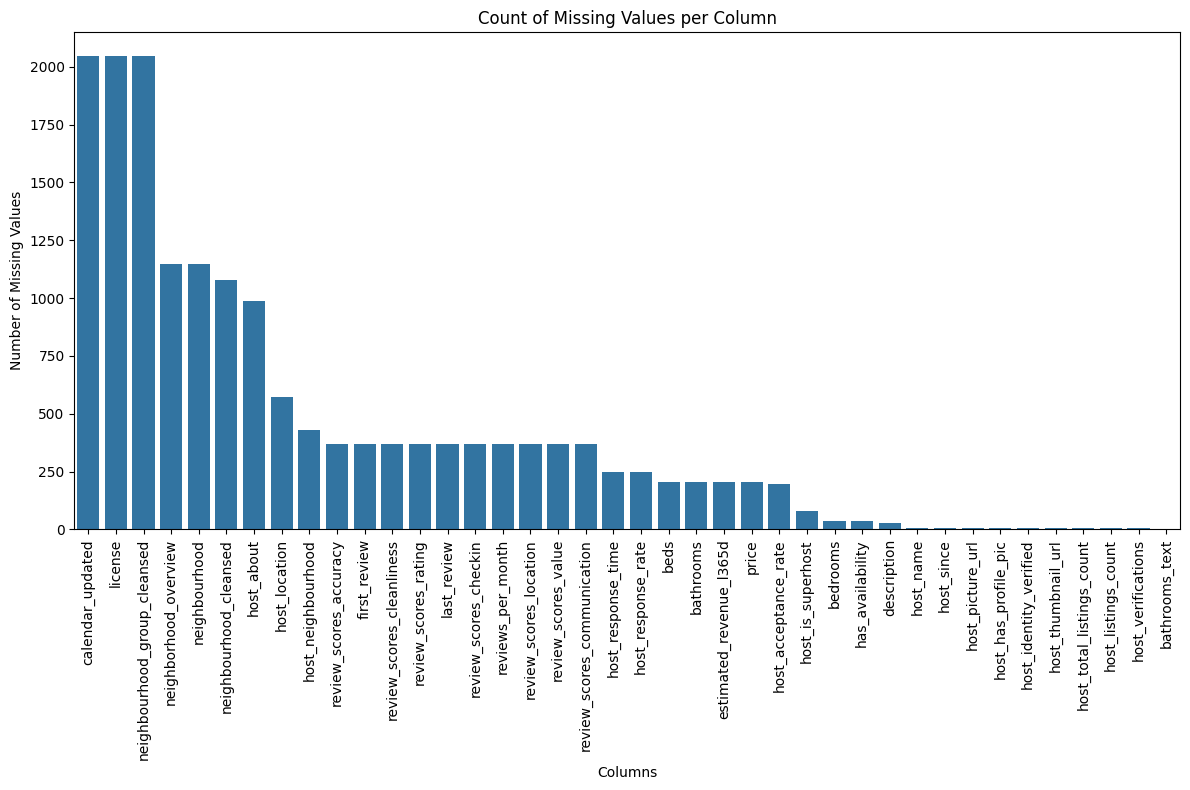

In [53]:
# Create a bar chart of the count for missing values 🔧
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x=missing_values.index, y=missing_values.values)
plt.xticks(rotation=90)
plt.title('Count of Missing Values per Column')
plt.xlabel('Columns')
plt.ylabel('Number of Missing Values')
plt.tight_layout()
plt.show()

### ✍️ Your Response: 🔧
1. Calendar_ updated, License, and Neighbourhood_group_cleansed are all missing the same number of values at 2047.

2. Calendar_updated and license may pose some serious issues as double bookings would cause huge issues for customers trying to rent the property and if owners are operating without a license, potentially, Airbnb may get into serious legal trouble.

3. Neighbourhood_group_cleansed can easily be dropped. Essentially it is people trying to get stricter regulations on rental properties, this isn't a current issue and likely even with more strict regulations it may not have an impact on business at all.


## 3. Drop Columns That Aren’t Useful

Business framing:  

Not every column adds value. Analysts often remove columns that are too empty, irrelevant, or repetitive — especially when preparing data for others.

Make a decision:

- Choose 2–4 columns to drop from your dataset
- Document your reasons for each one
- Confirm they're gone with `.head()` or `.info()`

### In Your Response:
1. Which columns did you drop?
2. Why were they not useful from a business perspective?
3. What could go wrong if you left them in?



In [54]:
# Drop columns that aren’t useful 🔧
columns_to_drop = ["neighbourhood_group_cleansed", "host_about", "first_review", "host_neighbourhood"]
# Filter out columns that do not exist in the DataFrame
existing_columns_to_drop = [col for col in columns_to_drop if col in df.columns]
df = df.drop(columns=existing_columns_to_drop)
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2047 entries, 0 to 2046
Data columns (total 75 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            2047 non-null   int64  
 1   listing_url                                   2047 non-null   object 
 2   scrape_id                                     2047 non-null   int64  
 3   last_scraped                                  2047 non-null   object 
 4   source                                        2047 non-null   object 
 5   name                                          2047 non-null   object 
 6   description                                   2019 non-null   object 
 7   neighborhood_overview                         899 non-null    object 
 8   picture_url                                   2047 non-null   object 
 9   host_id                                       2047 non-null   i

None

In [55]:
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,257869,https://www.airbnb.com/rooms/257869,20250613040024,2025-06-13,previous scrape,House w/ Pool in Cultural District/close2downtown,No STR's! <br />Be my guest and enjoy everythi...,Very quiet neighborhood. <br />Tree lined stre...,https://a0.muscache.com/pictures/18939849/1e85...,1356081,...,4.97,4.96,4.92,NaN,f,1,1,0,0,2.31
1,299748,https://www.airbnb.com/rooms/299748,20250613040024,2025-06-13,previous scrape,Rosy's Guest House,"Quiet, ground floor studio apartment in a gorg...",Gorgeous historic homes with tree lined sidew...,https://a0.muscache.com/pictures/4eead819-7ad8...,1544441,...,4.98,4.96,4.96,NaN,f,1,1,0,0,2.20
2,912371,https://www.airbnb.com/rooms/912371,20250613040024,2025-06-13,city scrape,Stay in Ft.Worth Cultural District,"Quiet, studio, upstairs garage apartment surro...","This is a beautiful, safe, quiet neighborhood ...",https://a0.muscache.com/pictures/13577479/7098...,4895584,...,4.96,4.95,4.83,NaN,f,1,1,0,0,2.15
3,1885626,https://www.airbnb.com/rooms/1885626,20250613040024,2025-06-13,city scrape,Private bedroom in spacious home,"If you're like us, friendly Canadians, you jus...",This neighbourhood is very quiet and family or...,https://a0.muscache.com/pictures/37169857/d6f1...,7892516,...,4.98,4.91,4.96,NaN,f,1,0,1,0,0.68
4,2130492,https://www.airbnb.com/rooms/2130492,20250613040024,2025-06-13,city scrape,"Charming ""attic room"" by TCU campus",Our cozy 2-story home overlooks the TCU stadiu...,"This is a wonderfully friendly old, yet lively...",https://a0.muscache.com/pictures/54799567/0f33...,826752,...,5.00,4.98,5.00,NaN,f,2,0,2,0,0.32


### ✍️ Your Response: 🔧
1. I dropped neighbourhood_group_cleansed, host_about, first_review, host_neighbourhood.

2. The two columns related to the host are unnecessary. I would argue that people don't value the host_about section as long as they have good reviews and why does the host's neighborhood matter, especially if it is different from the neighborhood the property is in. The first review is often irrelevant and people improve over time, having the last review gives the most relevant information and review score values gives a holistic view. We previously established that neighbourhood_group_cleansed is a little confusing and would be irrelevant to customers.

3. Nothing would go wrong, rather the data is redundant or irrelevant.




## 4. Fill or Fix Values in Key Columns

Business framing:  

Let’s say your manager wants to see a map of listings with prices and review scores. If key fields are blank, the map won’t work. But not all missing values should be filled the same way.

- Choose 2 columns with missing values
- Use a strategy to fill or flag those values
  - (e.g., median, “unknown”, forward-fill, or a placeholder)
- Explain what you did and why

### In your response:
1. What two columns did you clean?
2. What method did you use for each, and why?
3. What risks are there in how you filled the data?

In [56]:
# Fill or Fix Values in Key Columns 🔧

# Calculate the average of the other review score columns
review_score_columns = [col for col in df.columns if 'review_scores_' in col and col != 'review_scores_rating']
df['average_other_review_scores'] = df[review_score_columns].mean(axis=1)

# Fill missing values in 'review_scores_rating' with the calculated average
df['review_scores_rating'] = df['review_scores_rating'].fillna(df['average_other_review_scores'])

# Drop the temporary average column
df = df.drop(columns=['average_other_review_scores'])

# Check for remaining missing values in 'review_scores_rating'
display(df['review_scores_rating'].isnull().sum())

np.int64(367)

In [57]:
# Fill missing values in 'price' column with 'unknown' 🔧
df['price'] = df['price'].fillna('unknown')

# Check for remaining missing values in 'price'
display(df['price'].isnull().sum())

np.int64(0)

### ✍️ Your Response: 🔧
1. I cleaned the review scores and price columns.

2. For review scores I used the average of all the other review scores as typically Airbnb reviews are positive and the min outliers would "balance" out the larger quantity of higher positive reviews. For price I simply had it fill with unknown. There are so many factors that would dictate the price of a property; a simple median or forward fill would be misleading.

3. The risks with review scores is that those ratings may tell a false story about the quality of the review and of course as we know average is sensitive to outliers potentially skewing our data. With price as unknown it may deter people who are on a budget from the property as a whole.



## 5. Convert and Clean Data Types

Business framing:  

Sometimes columns that look like numbers are actually stored as text — which breaks calculations and slows down analysis. Common examples are price columns with dollar signs or availability stored as strings.

- Identify one column with the wrong data type
- Clean and convert it into a usable format (e.g., from string to number)
- Check your work by summarizing or plotting the cleaned column

### In Your Response: :
1. What column did you fix?
2. What cleaning steps did you apply?
3. How does this help prepare the data for later use?


In [58]:
# Show the datatype for price only 🔧
display(df['price'].dtype)

dtype('O')

In [59]:
# Clean and convert 'price' column to float64 🔧

# Replace 'unknown' with NaN
df['price'] = df['price'].replace('unknown', np.nan)

# Remove '$' and ',' from the string representation
df['price'] = df['price'].astype(str).str.replace('[$,]', '', regex=True)

# Convert to numeric (float64), coercing errors to NaN
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# Check the data type and some values
display(df['price'].dtype)
display(df['price'].head())

dtype('float64')

,price
0,NaN
1,NaN
2,58.0
3,47.0
4,100.0


In [60]:
df['price'].describe()

,price
count,1844.000000
mean,757.093818
std,5246.654997
min,15.000000
25%,75.000000
50%,112.000000
75%,173.000000
max,50000.000000


In [61]:
print(df['price'].dtype)

float64


### ✍️ Your Response: 🔧
1. I fixed the price column.

2. Becuase price was stored as an object it was viewed as string opposed to an integer, so I removed the "$" and "," and then converted to int64. Also the "unknown" from earlier was converted to NaN.

3. After removing these unnecessary characters we can do actual analysis on the data without any issues when trying to perfrom other functions.

## 6. Remove Duplicate Records

Business framing:  

If a listing appears twice, it could inflate revenue estimates or confuse users. Airbnb needs each listing to be unique and accurate.

- Check for rows that are exact duplicates
- If your data has an ID column and each ID is supposed to unique, then make sure there are no duplicate IDs
- Remove duplicates if found

### In your markdown:
1. Did you find duplicates?
2. How did you decide what to drop or keep?
3. Why are duplicates risky for Airbnb teams?


In [62]:
# Check for rows that are exact duplicates 🔧
duplicate_rows = df[df.duplicated()]
num_duplicates = duplicate_rows.shape[0]
print(f"Number of duplicate rows: {num_duplicates}")

# If your data has an ID column and each ID is supposed to unique, then make sure there are no duplicate IDs
# Assuming 'id' column should be unique
duplicate_ids = df[df.duplicated(subset=['id'])]
num_duplicate_ids = duplicate_ids.shape[0]
print(f"Number of rows with duplicate IDs: {num_duplicate_ids}")

Number of duplicate rows: 0
Number of rows with duplicate IDs: 0


### ✍️ Your Response: 🔧 🔧
1. It appears that there aren't any duplicated rows in the dataset.

2. If there were any duplicated rows either exact or with the same ID I would remove them from the dataset.

3. The risk goes back to the same issue from calendar_updated from earlier. If a property is double booked not only do you deal with upset customers but you likely would lose those customers or have to provide a refund.

## 7. Export Cleaned Data

Before wrapping up, export your cleaned Airbnb dataset to a CSV file. You'll need this file for **Assignment 7**, where you'll perform data transformation techniques.

Make sure your data has:
- Cleaned and consistent column values
- Proper data types for each column
- Any unnecessary columns removed

This file should be the version of your dataset that you’d feel confident sharing with a teammate or using for deeper analysis.



```
# Explanation:
# - "cleaned_airbnb_data.csv" is the name of the file that will be saved
# - index=False prevents pandas from writing row numbers into the CSV
# - The file will be saved to your working directory (in Colab, you'll need to download it manually. Once you see the data in your files tab, just click on the three dots, then click “download”)
# - YOU MAY NEED TO PRESS “RUN” MULTIPLE TIMES IN ORDER FOR IT TO SHOW UP
# - FOR SOME DEVICES, IT MAY TAKE A FEW MINUTES BEFORE YOUR FILE SHOWS UP

```





In [63]:
# Export Cleaned Data 🔧
df.to_csv("cleaned_airbnb_data.csv", index=False)

## 8. Final Reflection

You’ve just cleaned a real-world Airbnb dataset — the kind of work that happens every day in analyst and data science roles.

Before you move on to data transformation in Assignment 7, take a few moments to reflect on the decisions you made and what you learned.

### In your markdown:
1. What was the most surprising or challenging part of cleaning this dataset?
2. How did you decide which data to drop, fix, or keep?
3. What’s one way a business team (e.g., hosts, pricing analysts, platform ops) might benefit from the cleaned version of this data?
4. If you had more time, what would you explore or clean further?
5. How does this relate to your customized learning outcome you created in canvas?


Write your response clearly in full sentences. No more than a few sentences required per response.


### ✍️ Your Response: 🔧

1. The most difficult part was finding values or columns that needed their data type changed as the process felt manual and can be difficult with large datasets.  
2. Data that I focused on fixing and keeping were those with the most quantifiable values as we can further expand on those. Descriptive data such as host about was unnecessary and would only "hold back" the dataset.  
3. Having some of the most important quantifiable values cleaned and fixed gives the business team a chance to figure out what properties are the most profitable or popular.  
4. I would look at removing some extreme outlier data by using the .quantile function.
5. Having data that we can further analyze to find profitability and in turn promoting more relates back to my goal of being better at predictive analytics and figuring out where it is most valuable to allocate resources.  


## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [65]:
!jupyter nbconvert --to html "assignment_06_PetersonSteven.ipynb"

[NbConvertApp] Converting notebook assignment_06_PetersonSteven.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 481045 bytes to assignment_06_PetersonSteven.html
